<h1><b>MAIN.PY</b></h1>

<h2><b>TRAINING</b></h2>

In [2]:
%load_ext autoreload
%autoreload 2

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download("awsaf49/nyuv2-official-split-dataset")
print("Path to dataset files:", dataset_path)

Path to dataset files: /home/mado/.cache/kagglehub/datasets/awsaf49/nyuv2-official-split-dataset/versions/1


In [6]:
from src.train import train

model_path = "./models/model2.pth"

train(
    dataset_path=dataset_path,
    epochs=10,
    num_imgs=50000,
    model_path=model_path
)

Starting training...

Fichiers trouvés : 47584 paires rgb/depth
Train subset: 38067 | Val subset: 9517
Device :  cuda:0


Training: 100%|██████████| 10/10 [2:47:07<00:00, 1002.76s/epoch, train_loss=0.0938, train_rmse=1.2745, val_loss=0.0917, val_rmse=1.2580] 


----------------------------------------
Training Finished - saved model


<h2><b>EVALUATION</b></h2>

In [7]:
from src.utils import get_dataframe

print("TEST DATASET")
test_dataframe = get_dataframe(dataset_path, "test")
test_dataframe.head()

TEST DATASET
Fichiers trouvés : 654 paires rgb/depth


,rgb,depth
333,/home/mado/.cache/kagglehub/datasets/awsaf49/n...,/home/mado/.cache/kagglehub/datasets/awsaf49/n...
78,/home/mado/.cache/kagglehub/datasets/awsaf49/n...,/home/mado/.cache/kagglehub/datasets/awsaf49/n...
503,/home/mado/.cache/kagglehub/datasets/awsaf49/n...,/home/mado/.cache/kagglehub/datasets/awsaf49/n...
290,/home/mado/.cache/kagglehub/datasets/awsaf49/n...,/home/mado/.cache/kagglehub/datasets/awsaf49/n...
360,/home/mado/.cache/kagglehub/datasets/awsaf49/n...,/home/mado/.cache/kagglehub/datasets/awsaf49/n...


In [8]:
import torchvision.transforms as transforms

from src.dataset import Nyudepth_png

transform = transforms.Compose([transforms.Resize([224,224])])
test_dataset = Nyudepth_png(
    dataset_path=dataset_path,
    dataframe=test_dataframe.reset_index(drop="true"),
    transform_shape=transform, 
    transform_color=None
)
len(test_dataset)

654

torch.Size([3, 224, 224]) torch.Size([1, 224, 224]) tensor(1.) tensor(0.4863) torch.float32 torch.float32


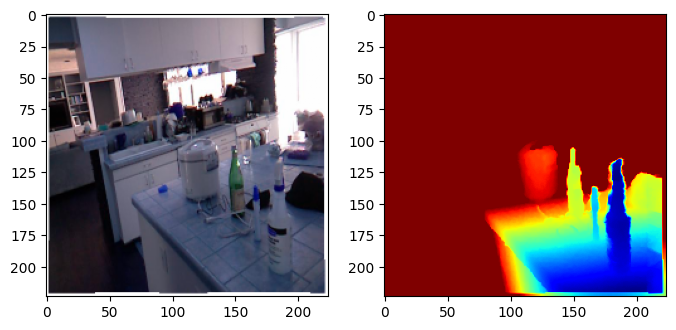

In [9]:
import matplotlib.pyplot as plt
from random import randint

im, de = test_dataset[randint(0, len(test_dataset)-1)]
print(im.shape, de.shape, de.max(), de.min(), im.dtype, de.dtype)

cmap = plt.get_cmap("jet").copy()
cmap.set_bad(color="black")
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow((im.squeeze().permute(1,2,0) + 1.0)/2.0)
ax[1].imshow((de.squeeze() + 1.0)/2.0, cmap= cmap)

In [10]:
from torch.utils.data import DataLoader

test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=8)


In [11]:
import torch
from src.model import UNet


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint, strict=False)
model.eval()

print(device)
print(model_path)

cuda:0
./models/model2.pth


In [12]:
from torchview import draw_graph

model_graph = draw_graph(model, input_size=(2, 3, 224, 224), expand_nested=True)
model_graph.visual_graph.render(filename='outputs/unet', format='png')

'outputs/unet.png'

GT Min: 0.7687 | Max: 1.0000 | Mean: 0.9921
Pred Min: 0.7000 | Max: 10.0000 | Mean: 9.5921


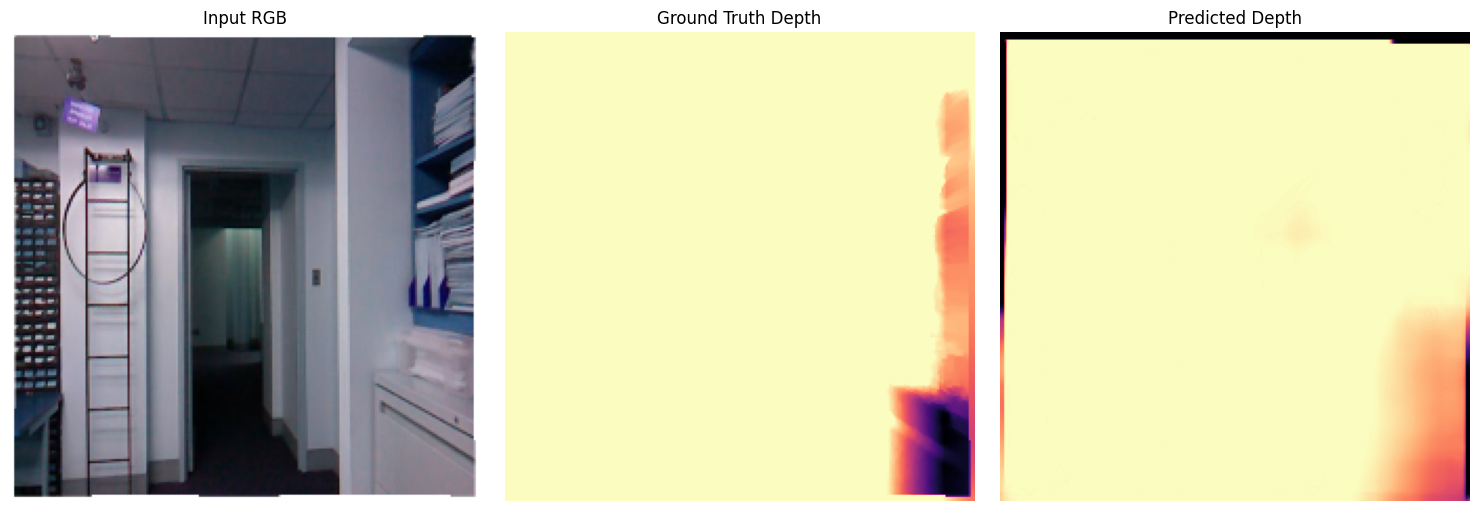

In [27]:
from src.utils import predict
from random import randint
import matplotlib.pyplot as plt

# Pick a random sample
im, dm = test_dataset[randint(0, len(test_dataset)-1)]

# Print GT stats (dm is a PyTorch tensor)
print(f"GT Min: {dm.min().item():.4f} | Max: {dm.max().item():.4f} | Mean: {dm.mean().item():.4f}")

# Run prediction
de_p = predict(im, model, device)

# Print Pred stats (de_p is a NumPy array)
print(f"Pred Min: {de_p.min():.4f} | Max: {de_p.max():.4f} | Mean: {de_p.mean():.4f}")

# Setup color map
cmap = plt.get_cmap("magma").copy()
cmap.set_bad(color="black")

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 1. RGB Input (reversing standard [-1, 1] normalization if applicable)
ax[0].set_title("Input RGB")
ax[0].imshow((im.permute(1, 2, 0).cpu().numpy() + 1.0) / 2.0)
ax[0].axis("off")

# 2. Ground Truth Depth (Plot raw data to let matplotlib auto-scale the contrast)
ax[1].set_title("Ground Truth Depth")
ax[1].imshow(dm.squeeze().cpu().numpy(), cmap=cmap)
ax[1].axis("off")

# 3. Predicted Depth
ax[2].set_title("Predicted Depth")
ax[2].imshow(de_p, cmap=cmap) # Already squeezed by your predict utility
ax[2].axis("off")

plt.tight_layout()
plt.show()